---
title: "Mask design for coupling flows"
short_title: "03 · Mask design"
subtitle: "A coupling touches only half the coordinates — alternate the mask so every coordinate is both transformed and used as context"
description: >
  A single coupling layer leaves the passive half untouched, so stacking the same
  mask forever leaves those coordinates exactly as they came in. This notebook
  shows that failure, fixes it by alternating the mask, and surveys the mask
  families — channel-wise, checkerboard, learned — and how stacking them gives
  every coordinate both roles.
---

(sec-nb-cpl-03)=
# 03 — Mask design for coupling flows

The coupling contract ([notebook 00](00_coupling_pattern.ipynb)) has a catch: a
coupling layer transforms only the **active** half and copies the **passive** half
through unchanged. A single layer is therefore *not* a bijector that can reshape
every coordinate — and if every layer uses the **same** split, the passive
coordinates are never touched, no matter how deep the stack. The **mask** decides
the split, and **alternating** it is what makes a coupling flow a full transform:
each coordinate must be transformed in some layers and serve as context in others.

**What you will see**

- The failure: a stack with a **fixed mask** leaves half the coordinates *exactly*
  at their input values.
- The fix: **alternating** the mask (a `Flip` between layers) Gaussianizes every
  coordinate and fits better.
- The mask **families** — channel-wise, checkerboard, learned — and why images use
  a different pattern than vectors.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Flip, Invert
from flowjax.distributions import Normal, Transformed

import gauss_flows as gf
from _style import GAUSS_KW, SCATTER_KW, standard_normal_pdf, style_ax

jax.config.update("jax_enable_x64", True)

from sklearn.datasets import make_moons
X_np, _ = make_moons(n_samples=3000, noise=0.07, random_state=0)
X = jnp.asarray((X_np - X_np.mean(0)) / X_np.std(0))


def coupling(key):
    return gf.MixtureGaussianCDFCoupling(key, shape=(2,), n_components=8, nn_width=32, nn_depth=2)


def stack(key, n_blocks, *, alternate):
    """Stack of couplings; with `alternate`, a Flip between layers swaps the mask."""
    bijections = []
    for k in jr.split(key, n_blocks):
        bijections.append(coupling(k))
        if alternate:
            bijections.append(Flip(shape=(2,)))
    return Transformed(Normal(jnp.zeros(2)), Invert(Chain(bijections)))


to_latent = lambda flow: np.asarray(jax.vmap(flow.bijection.inverse)(X))   # data -> z

## 1. A fixed mask leaves half the coordinates untouched

`gf` couplings split into a fixed passive/active half. A single layer leaves coord
$0$ exactly as it came in; stacking more of the **same** layer changes nothing
about coord $0$. We build a 4-block fixed-mask stack and check the latent.

In [2]:
single = coupling(jr.key(0))
delta = np.asarray(single.transform(jnp.array([0.5, 0.5])) - jnp.array([0.5, 0.5]))
print(f"single coupling: change per coord = {np.round(delta, 4)}  -> coord 0 is passive")

fixed = stack(jr.key(0), 4, alternate=False)
z_fixed = to_latent(fixed)
print(f"\n4-block FIXED-mask stack:")
print(f"  latent coord 0 identical to input? {np.allclose(z_fixed[:, 0], np.asarray(X[:, 0]), atol=1e-6)}")
print(f"  latent coord 0 std = {z_fixed[:, 0].std():.3f}  (input was standardised; not Gaussianized)")

single coupling: change per coord = [ 0.     -0.1723]  -> coord 0 is passive



4-block FIXED-mask stack:
  latent coord 0 identical to input? True
  latent coord 0 std = 1.000  (input was standardised; not Gaussianized)


The passive coordinate comes out **bit-for-bit unchanged** — four layers did
nothing to it, because every layer used the same mask. So its latent marginal is
still the (non-Gaussian) data marginal, not $\mathcal{N}(0,1)$. The flow has
*no way* to Gaussianize half its inputs.

## 2. Alternating the mask fixes it

Insert a `Flip` between layers and the roles swap: coord $0$ is passive in one
layer, active in the next. Now every coordinate is both transformed and used as
context. We compare the latent marginals.

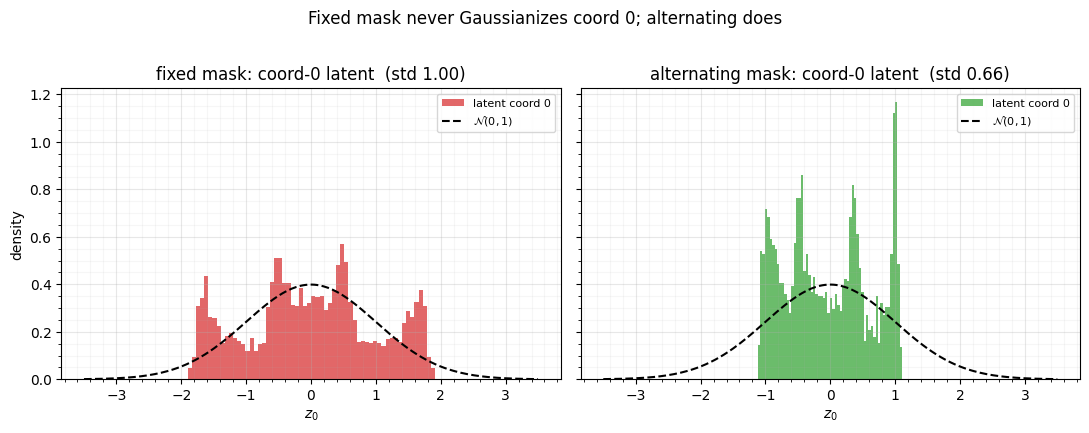

In [3]:
alt = stack(jr.key(0), 4, alternate=True)
z_alt = to_latent(alt)

zz = np.linspace(-3.5, 3.5, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, zc, title in [(axes[0], z_fixed, "fixed mask"), (axes[1], z_alt, "alternating mask")]:
    ax.hist(zc[:, 0], bins=60, density=True, alpha=0.7, color="tab:red" if title == "fixed mask" else "tab:green",
            label="latent coord 0")
    ax.plot(zz, standard_normal_pdf(zz), **GAUSS_KW, label=r"$\mathcal{N}(0,1)$")
    ax.set(title=f"{title}: coord-0 latent  (std {zc[:, 0].std():.2f})", xlabel="$z_0$")
    ax.legend(fontsize=8); style_ax(ax)
axes[0].set_ylabel("density")
fig.suptitle("Fixed mask never Gaussianizes coord 0; alternating does", y=1.02)
fig.tight_layout()

With a fixed mask the coord-0 latent is the untouched (flat, non-Gaussian) data
marginal; alternating the mask pulls it toward $\mathcal{N}(0,1)$. The likelihood
follows — we fit both.

In [4]:
def train(flow, *, steps=1200, peak_lr=3e-3, batch=512, seed=1):
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(steps, peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, g = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    key = jr.key(seed)
    for _ in range(steps):
        key, sk = jr.split(key)
        params, state, _ = step(params, state, X[jr.randint(sk, (batch,), 0, X.shape[0])])
    return eqx.combine(params, static)


logp = lambda f: float(jax.vmap(f.log_prob)(X).mean())
print(f"fit (two-moons):  fixed mask = {logp(train(fixed)):.3f}   "
      f"alternating = {logp(train(alt)):.3f}")

fit (two-moons):  fixed mask = -1.685   alternating = -1.469


The alternating stack fits clearly better — and would Gaussianize *both* axes,
which the fixed stack structurally cannot. Alternation is not optional; it is what
turns a half-transform into a full one.

## 3. The mask families

*Which* split to use depends on the data's structure. For an unstructured vector
the **channel-wise** split (first half vs second half, alternated by `Flip`) is
standard. For an **image**, neighbouring pixels are highly correlated, so a
**checkerboard** mask keeps each transformed pixel surrounded by context pixels;
channel-wise masks then split feature channels at coarser scales. **Learned**
masks (a differentiable Gumbel-softmax over the split) are an option when the right
partition is not obvious.

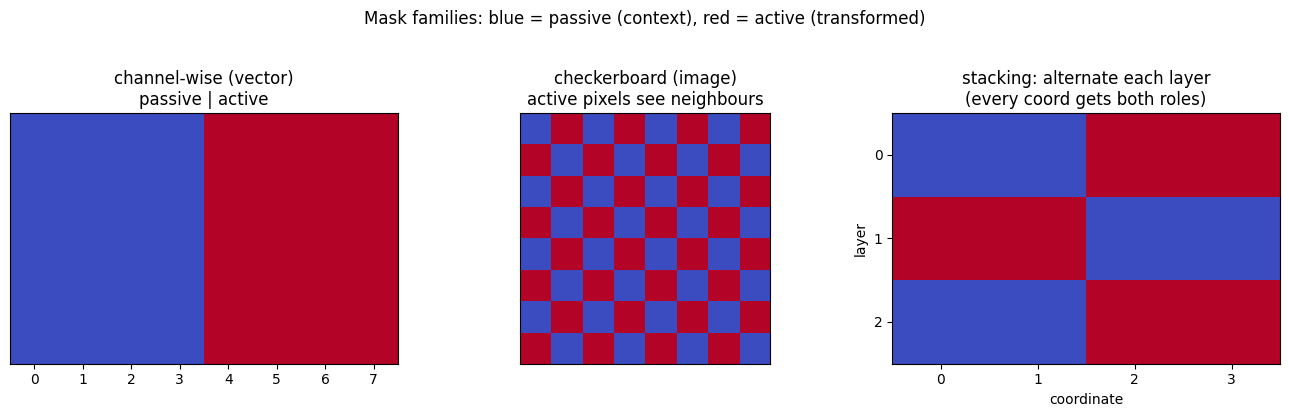

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
# channel-wise (vector): first half passive, second active, then flipped
cw = np.zeros((1, 8)); cw[0, 4:] = 1
axes[0].imshow(np.repeat(cw, 2, axis=0), cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
axes[0].set(title="channel-wise (vector)\npassive | active", xticks=range(8), yticks=[])
# checkerboard (image)
g = np.indices((8, 8)).sum(0) % 2
axes[1].imshow(g, cmap="coolwarm", vmin=0, vmax=1)
axes[1].set(title="checkerboard (image)\nactive pixels see neighbours", xticks=[], yticks=[])
# alternation across layers (channel-wise + flip)
layers = np.array([[0, 0, 1, 1], [1, 1, 0, 0], [0, 0, 1, 1]])
axes[2].imshow(layers, cmap="coolwarm", vmin=0, vmax=1, aspect="auto")
axes[2].set(title="stacking: alternate each layer\n(every coord gets both roles)",
            xlabel="coordinate", ylabel="layer", xticks=range(4), yticks=range(3))
for ax in (axes[0], axes[1]):
    ax.grid(False)
fig.suptitle("Mask families: blue = passive (context), red = active (transformed)", y=1.03)
fig.tight_layout()

All three panels encode the same idea: **blue** coordinates are copied and used as
context, **red** coordinates are transformed. The checkerboard's value is locality
— every active pixel is conditioned on its immediate neighbours — which is why
image flows ([Part 12](../../README.md)) alternate checkerboard and channel-wise
masks across scales. For our 2-D vectors, channel-wise + `Flip` is the whole story.

## Recap

| mask | data | role |
|---|---|---|
| channel-wise (split halves) | vectors / feature channels | standard RealNVP split |
| checkerboard | images | active pixels conditioned on neighbours |
| learned (Gumbel-softmax) | when partition is unclear | differentiable split |
| **alternation across layers** | all | gives every coordinate both roles — *required* |

A coupling layer is half a transform; the mask schedule is what assembles halves
into a full, every-coordinate bijector. Get it wrong (fixed mask) and a chunk of
your data is never modelled.

**Next up.** With the coupling pattern, bijector menu, conditioners, and masks in
hand, we can ask the comparative questions. [04 — Diagonal vs coupling](04_diagonal_vs_coupling.ipynb)
(parameter-fair) and [05 — RBIG warm-start for coupling](05_coupling_warmstart.ipynb)
(the zero-kernel contract) revisit coupling against the diagonal flows of Part 4,
leading into the formal coupling↔diagonal equivalence.